# Toki DPD91 Prediction

## Data Scientist Candidate Assignment

Энэхүү notebook-ийн зорилго нь Toki-ийн credit card үйлчилгээний 31 хоногийн хугацаа хэтрүүлэлттэй (`DPD31`) зээлдэгч цаашид 91 хоног болон түүнээс дээш хугацаагаар хугацаа хэтрүүлэх (`DPD91+`) эсэхийг таамаглах Machine Learning model боловсруулахад оршино.

Шинжилгээг хийхдээ өгөгдлийн чанар, feature availability, Data Leakage, temporal validation, feature engineering, model selection болон final evaluation зэрэг үе шатуудыг дараалалтайгаар авч үзнэ.

Эцсийн зорилго нь зөвхөн өндөр predictive performance авах бус, тухайн model-ийн үр дүнг бизнесийн үйл ажиллагаанд хэрхэн ашиглаж болохыг тайлбарлах, мөн model-ийн хязгаарлалтыг тодорхойлох явдал юм.

## 1. Environment Setup

Энэ хэсэгт шинжилгээ болон Machine Learning model боловсруулахад шаардлагатай Python libraries-ийг импортолно.

Шинжилгээний явцад reproducibility-г хадгалахын тулд шаардлагатай тохиолдолд `random_state`-ийг тогтмол утгаар ашиглана.

In [1]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Data Loading

Даалгаварт өгөгдөл Excel workbook хэлбэрээр өгөгдсөн бөгөөд workbook-ийн sheet-үүдэд credit card үйлчилгээний DPD31-тэй холбоотой мэдээлэл хадгалагдсан.

Эхний алхамд workbook-ийн бүх sheet-ийн нэр болон хэмжээтэй танилцаж, modeling-д ямар өгөгдөл ашиглахыг тодорхойлно.

Энэ шатанд өгөгдлийг шууд өөрчлөхгүй. Эхлээд эх өгөгдлийн бүтцийг шалгаж, дараагийн preprocessing алхмуудыг нотолгоонд үндэслэн тодорхойлно.

In [3]:
# Path to the provided Excel workbook
file_path = "../data/raw/Toki Data Scientist task.xlsx"

# Read workbook structure
excel_file = pd.ExcelFile(file_path)

print("Available sheets:")
for sheet in excel_file.sheet_names:
    print(f"- {sheet}")

Available sheets:
- Rule
- data_description
- payment
- overdue
- balance
- user_list


In [4]:
# Load all sheets without modifying the original data
data_sheets = {
    sheet: pd.read_excel(file_path, sheet_name=sheet)
    for sheet in excel_file.sheet_names
}

# Display basic information for each sheet
sheet_summary = []

for sheet_name, df in data_sheets.items():
    sheet_summary.append({
        "sheet": sheet_name,
        "rows": df.shape[0],
        "columns": df.shape[1]
    })

sheet_summary = pd.DataFrame(sheet_summary)

sheet_summary

,sheet,rows,columns
0,Rule,16,2
1,data_description,97,3
2,payment,445910,3
3,overdue,710118,42
4,balance,884449,9
5,user_list,61200,43


In [5]:
# Preview the main user-level dataset
user_list = data_sheets["user_list"].copy()

print("user_list shape:", user_list.shape)
print("\nFirst 5 rows:")
display(user_list.head())

user_list shape: (61200, 43)

First 5 rows:


,created_month,date_dpd_31,credit_id,limit_dpd31,balance_dpd31,limit_ondue,balance_ondue,invoiced_unpaid_amt,total_payment_amt,ostype,liveness_cnt,liveness_success_cnt,liveness_forgetful_cnt,liveness_fail_cnt,user_tenure,profile_changed_since,has_changed_phone,gender,age,app_recency_days,trx_recency_l90d,trx_l7d,trx_l30d,trx_l60d,trx_l90d,avg_trx_amount_l7d,avg_trx_amount_l30d,avg_trx_amount_l60d,avg_trx_amount_l90d,sessions_l7d,sessions_l30d,sessions_l60d,sessions_l90d,read_noti_l7d,read_noti_l30d,read_noti_l60d,read_noti_l90d,is_unitel,number_change_cnt_l30d,number_change_cnt_l60d,number_change_cnt_l90d,number_change_cnt,is_dpd_91
0,202512,2025-12-16,2012138,183000.0,180989.12,183000,180989.12,48689.11,428300.00,2.0,3.0,3.0,1.0,0.0,1212.0,1093.0,1.0,1.0,28.0,62.0,69.0,0.0,0.0,0.0,10.0,NaN,NaN,NaN,100508.000000,0.0,0.0,0.0,12.0,0.0,0.0,0.0,12.0,1.0,0.0,0.0,0.0,4.0,1.0
1,202512,2025-12-16,2380667,344000.0,182053.88,344000,182053.88,49295.55,200051.06,1.0,2.0,1.0,1.0,0.0,361.0,280.0,0.0,2.0,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,1.0,0.0
2,202512,2025-12-16,2485544,185000.0,170415.00,185000,170415.00,47003.90,28538.52,1.0,4.0,4.0,4.0,0.0,1212.0,641.0,0.0,1.0,22.0,1.0,46.0,0.0,0.0,1.0,1.0,NaN,NaN,28600.000000,3000.000000,3.0,10.0,4.0,11.0,0.0,0.0,3.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,202512,2025-12-16,2347184,300000.0,273594.00,300000,273594.00,57435.42,0.00,2.0,1.0,1.0,0.0,0.0,321.0,321.0,0.0,1.0,28.0,1.0,32.0,0.0,0.0,5.0,3.0,NaN,NaN,12600.000000,667.000000,1.0,3.0,15.0,4.0,5.0,5.0,0.0,11.0,1.0,0.0,0.0,0.0,1.0,0.0
4,202512,2025-12-16,2105376,302000.0,301703.92,302000,301703.92,82927.03,1349321.06,1.0,11.0,5.0,0.0,0.0,1212.0,625.0,0.0,1.0,28.0,18.0,19.0,0.0,10.0,23.0,12.0,NaN,2000.0,1956.521739,9733.333333,0.0,7.0,19.0,18.0,0.0,0.0,8.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## 3. Dataset Audit

Model боловсруулахын өмнө өгөгдлийн үндсэн бүтэц болон чанарыг шалгана.

Энэ хэсэгт дараах асуултуудад хариулна:

- Dataset хэдэн observation болон feature-тэй вэ?
- Target variable ямар бүтэцтэй вэ?
- Labeled болон unlabeled observation хэд байна вэ?
- `credit_id` давтагдаж байна уу?
- Data type-ууд зөв тодорхойлогдсон уу?
- `created_month` болон `date_dpd_31` ямар хугацааны мэдээлэлтэй вэ?
- Target class imbalance хэр байна вэ?

Эдгээр шалгалтын үр дүн нь дараагийн preprocessing болон validation strategy-г тодорхойлоход ашиглагдана.

In [6]:
# ============================================================
# 3.1 Basic Dataset Structure
# ============================================================

print("Dataset shape:", user_list.shape)

print("\nColumn count:", len(user_list.columns))

print("\nData types:")
display(user_list.dtypes.to_frame("dtype"))

Dataset shape: (61200, 43)

Column count: 43

Data types:


,dtype
created_month,int64
date_dpd_31,datetime64[ns]
credit_id,int64
limit_dpd31,float64
balance_dpd31,float64
limit_ondue,int64
balance_ondue,float64
invoiced_unpaid_amt,float64
total_payment_amt,float64
ostype,float64


In [7]:
# ============================================================
# 3.2 Target Variable Audit
# ============================================================

target = "is_dpd_91"

print("Target:", target)

print("\nTarget value counts:")
display(user_list[target].value_counts(dropna=False).sort_index())

print("\nTarget missing values:")
print(user_list[target].isna().sum())

print("\nTarget missing rate:")
print(f"{user_list[target].isna().mean():.2%}")

Target: is_dpd_91

Target value counts:


is_dpd_91
0.0    36064
1.0    16673
NaN     8463
Name: count, dtype: int64


Target missing values:
8463

Target missing rate:
13.83%


In [8]:
# ============================================================
# 3.3 Labeled vs Unlabeled Observations
# ============================================================

labeled_mask = user_list[target].notna()
unlabeled_mask = user_list[target].isna()

labeled_count = labeled_mask.sum()
unlabeled_count = unlabeled_mask.sum()

print("Labeled observations:")
print(f"  Rows: {labeled_count:,}")
print(f"  Share: {labeled_count / len(user_list):.2%}")

print("\nUnlabeled observations:")
print(f"  Rows: {unlabeled_count:,}")
print(f"  Share: {unlabeled_count / len(user_list):.2%}")

Labeled observations:
  Rows: 52,737
  Share: 86.17%

Unlabeled observations:
  Rows: 8,463
  Share: 13.83%


,target,count,percentage
0,0.0,36064,0.683846
1,1.0,16673,0.316154


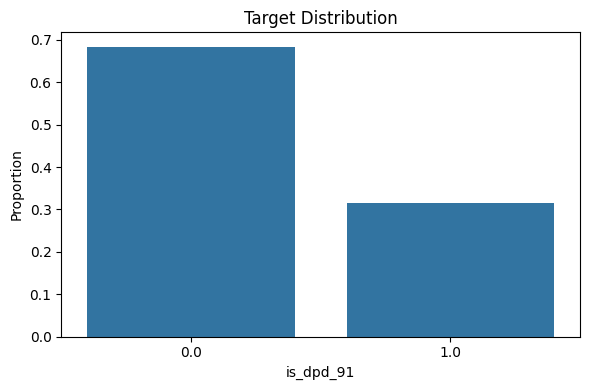

In [9]:
# ============================================================
# 3.4 Target Distribution
# ============================================================

target_distribution = (
    user_list.loc[labeled_mask, target]
    .value_counts()
    .sort_index()
    .rename_axis("target")
    .reset_index(name="count")
)

target_distribution["percentage"] = (
    target_distribution["count"]
    / target_distribution["count"].sum()
)

display(target_distribution)

plt.figure(figsize=(6, 4))

sns.barplot(
    data=target_distribution,
    x="target",
    y="percentage"
)

plt.title("Target Distribution")
plt.xlabel("is_dpd_91")
plt.ylabel("Proportion")

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# 3.5 Credit ID Audit
# ============================================================

credit_id = "credit_id"

total_rows = len(user_list)
unique_credits = user_list[credit_id].nunique()
duplicate_rows = total_rows - unique_credits

print(f"Total rows: {total_rows:,}")
print(f"Unique credit_id: {unique_credits:,}")
print(f"Rows beyond unique credit_id count: {duplicate_rows:,}")

print("\nDuplicated credit_id rows:")
print(f"{user_list[credit_id].duplicated(keep=False).sum():,}")

Total rows: 61,200
Unique credit_id: 46,516
Rows beyond unique credit_id count: 14,684

Duplicated credit_id rows:
27,289


In [13]:
# ============================================================
# 3.6 Credit ID Frequency
# ============================================================

credit_frequency = (
    user_list[credit_id]
    .value_counts()
    .rename("event_count")
)

print("Credit ID frequency distribution:")
display(credit_frequency.describe())

print("\nNumber of credits by event count:")
display(
    credit_frequency
    .value_counts()
    .sort_index()
    .head(20)
    .rename_axis("event_count")
    .reset_index(name="number_of_credits")
)

Credit ID frequency distribution:


count    46516.000000
mean         1.315676
std          0.559145
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          6.000000
Name: event_count, dtype: float64


Number of credits by event count:


,event_count,number_of_credits
0,1,33911
1,2,10685
2,3,1769
3,4,144
4,5,6
5,6,1


In [14]:
# ============================================================
# 3.7 Temporal Coverage
# ============================================================

print("created_month unique values:")
print(sorted(user_list["created_month"].dropna().unique()))

print("\nNumber of rows by created_month:")
display(
    user_list["created_month"]
    .value_counts()
    .sort_index()
    .rename_axis("created_month")
    .reset_index(name="row_count")
)

print("\ndate_dpd_31 range:")

date_dpd_31 = pd.to_datetime(user_list["date_dpd_31"], errors="coerce")

print("Minimum:", date_dpd_31.min())
print("Maximum:", date_dpd_31.max())
print("Missing:", date_dpd_31.isna().sum())

created_month unique values:
[np.int64(202512), np.int64(202601), np.int64(202602), np.int64(202603), np.int64(202604), np.int64(202605), np.int64(202606)]

Number of rows by created_month:


,created_month,row_count
0,202512,8796
1,202601,7846
2,202602,8733
3,202603,9775
4,202604,9263
5,202605,8943
6,202606,7844



date_dpd_31 range:
Minimum: 2025-12-16 00:00:00
Maximum: 2026-06-15 00:00:00
Missing: 0


In [15]:
# ============================================================
# 3.8 Missing Values Overview
# ============================================================

missing_summary = (
    user_list.isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_rate"] = (
    missing_summary["missing_count"] / len(user_list)
)

missing_summary = (
    missing_summary
    .sort_values("missing_rate", ascending=False)
)

display(missing_summary)

,missing_count,missing_rate
avg_trx_amount_l7d,52655,0.860376
avg_trx_amount_l30d,41502,0.678137
avg_trx_amount_l60d,21144,0.345490
avg_trx_amount_l90d,20073,0.327990
app_recency_days,11522,0.188268
sessions_l7d,11522,0.188268
sessions_l30d,11522,0.188268
sessions_l60d,11522,0.188268
sessions_l90d,11522,0.188268
read_noti_l7d,11522,0.188268
